# Final General Anxiety Disorder (GAD) data analysis
The NHIS data was collected by the CDC in America and the gaming data was primarily provided by 18-22 year olds, so the comparisons below follow those guidelines for a more equal comparison.

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
# import matplotlib.patches
import numpy as np
import seaborn as sns
from my_functions import visualize_count_plot, visualize_and_label_count_plot

conn = sqlite3.connect('../data/mentalhealth.db')

pd.set_option('display.max_columns', None)

## Set Global Variables

In [2]:
colors_ld=['#92c5de','#4393c3', '#2166ac', '#5e3c99', '#2d1e2f', '#0f0a14']
colors_dl=['#0f0a14', '#2d1e2f', '#5e3c99', '#2166ac', '#4393c3', '#92c5de']

### Temporary View of all GAD Data

In [3]:
conn.execute("""
    CREATE TEMP VIEW gad_data_usa_18_22 AS
    SELECT
        p.participant_id,
        p.survey_id,
        p.sex_id,
        p.education_id,
        p.residence,
        p.age,
        p.region_id,
        r.GAD1,
        r.GAD2,
        r.GAD3,
        r.GAD4,
        r.GAD5,
        r.GAD6,
        r.GAD7,
        r.GAD_total,
        r.GAD_cat
    FROM participant p
    JOIN GAD_response r on r.participant_id = p.participant_id
    WHERE (p.age BETWEEN 18 AND 22)
        AND p.residence = 'USA'
""")

## How do the total GAD scores compare between gamers and the general population?

### GAD Scores Queries

In [4]:
gamer_GAD_scores_query = ("""
    SELECT
        g.GAD_total,
        g.GAD_cat,
        c.cat_name
    FROM gad_data_usa_18_22 g
    JOIN GAD_category c on c.GAD_cat = g.GAD_cat
    WHERE survey_id = 1
""")

gamer_GAD_scores_result = pd.read_sql(gamer_GAD_scores_query, conn)


nhis_GAD_scores_query = ("""
    SELECT
        g.GAD_total,
        g.GAD_cat,
        c.cat_name
    FROM gad_data_usa_18_22 g
    JOIN GAD_category c on c.GAD_cat = g.GAD_cat
    WHERE survey_id = 2
""")

nhis_GAD_scores_result = pd.read_sql(nhis_GAD_scores_query, conn)

all_GAD_scores_query = ("""
    SELECT
        g.GAD_total,
        g.GAD_cat,
        c.cat_name,
        g.survey_id
    FROM gad_data_usa_18_22 g
    JOIN GAD_category c on c.GAD_cat = g.GAD_cat
""")

all_GAD_scores_result = pd.read_sql(all_GAD_scores_query, conn)
all_GAD_scores_result

,GAD_total,GAD_cat,cat_name,survey_id
0,19,4,Severe,1
1,0,1,None/Minimal,1
2,3,1,None/Minimal,1
3,4,1,None/Minimal,1
4,1,1,None/Minimal,1
...,...,...,...,...
4797,2,1,None/Minimal,2
4798,0,1,None/Minimal,2
4799,6,2,Mild,2
4800,15,4,Severe,2


### Countplot Function

In [5]:
def remove_top_right_borders(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def annotate_plot (data_source_name, x_coord, y_coord):
        plt.annotate(
        f'Data Source(s): {data_source_name}', 
        (x_coord,0), 
        (0,y_coord), 
        fontsize=8, 
        xycoords='axes fraction', 
        textcoords='offset points', 
        va='top',
        fontstyle='italic'
        )

def display_GAD_countplot(dataframe, avg_label_y_align, plot_title, data_source_name, x_coord, y_coord, file_name):

    average_GAD = dataframe['GAD_total'].mean().round(1)

    plt.figure(figsize=(10,6))

    # This tells the palette how the categories should be colored
    palette_list = {
        'None/Minimal': colors_ld[0],
        'Mild': colors_ld[1],
        'Moderate': colors_ld[2],
        'Severe': colors_ld[3]
    }

    ax = sns.countplot(
        x='GAD_total', 
        data = dataframe,
        hue = 'cat_name', 
            # hue tells the palette what column to use to know 
            # what category to use from the palette_list
        dodge=False,
        gap=-.25,
        palette = palette_list,
        edgecolor=colors_ld[-1]
    )

    remove_top_right_borders(ax)

    # Add average line
    ax.axvline(
        average_GAD,
        color="red",
        linewidth = 1,
        alpha = .7
    )

    ax.text(
        average_GAD+0.25,
        avg_label_y_align,
        f"Avearage\nScore",
        color="red",
        fontsize=10
    )

    # Cite sources
    annotate_plot(data_source_name, x_coord, y_coord)

    # Customize xticks
    plt.xticks([0, 10, 20], [0, 10, 20])


    plt.legend(
        title='Anxiety Level', 
        loc='center right'
        )

    plt.title(plot_title, fontsize=18, pad=20)
    plt.xlabel("Generalized Anxiety Disorder-7 (GAD-7) Assessment Score", fontsize=12)
    plt.ylabel("Number of Survey Participants", fontsize=12)

    plt.tight_layout()

    # Save figure as image
    plt.savefig(f'../plots/{file_name}.png')

    plt.show()

# References: 
#   1- https://stackoverflow.com/questions/59695334/custom-color-palette-in-seaborn
#   2- I got very close, but needed help understanding how 'hue', 'dodge', and 'gap'worked: ChatGPT helped
#   3- https://www.geeksforgeeks.org/python/how-to-adjust-number-of-ticks-in-seaborn-plots/ 
#   4- https://stackoverflow.com/questions/41046214/cite-a-data-source-in-matplotlib 

### GAD Score Visualizations

In [6]:
source_GAD_title_countplot = 'Gaming Habits and Psychological Well-being: An international dataset about the Anxiety, Life Satisfaction and\nSocial Phobia of over 13000 gamers'
source_NHIS_title_countplot = '2019 National Health Interview Survey (NHIS)'

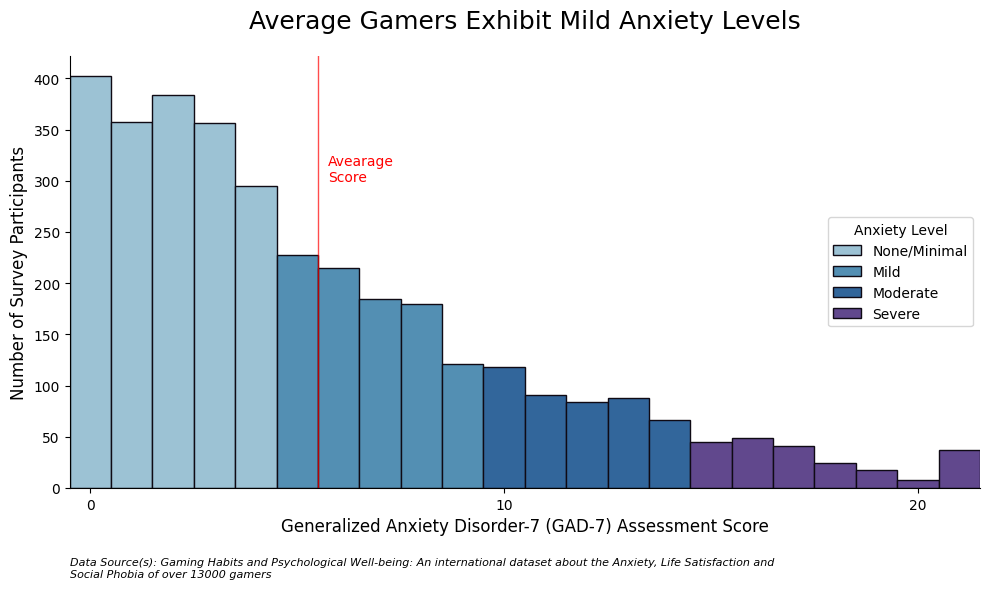

In [7]:
display_GAD_countplot(gamer_GAD_scores_result, 300, 'Average Gamers Exhibit Mild Anxiety Levels', source_GAD_title_countplot, 0, -50, 'gamer_gad_countplot')

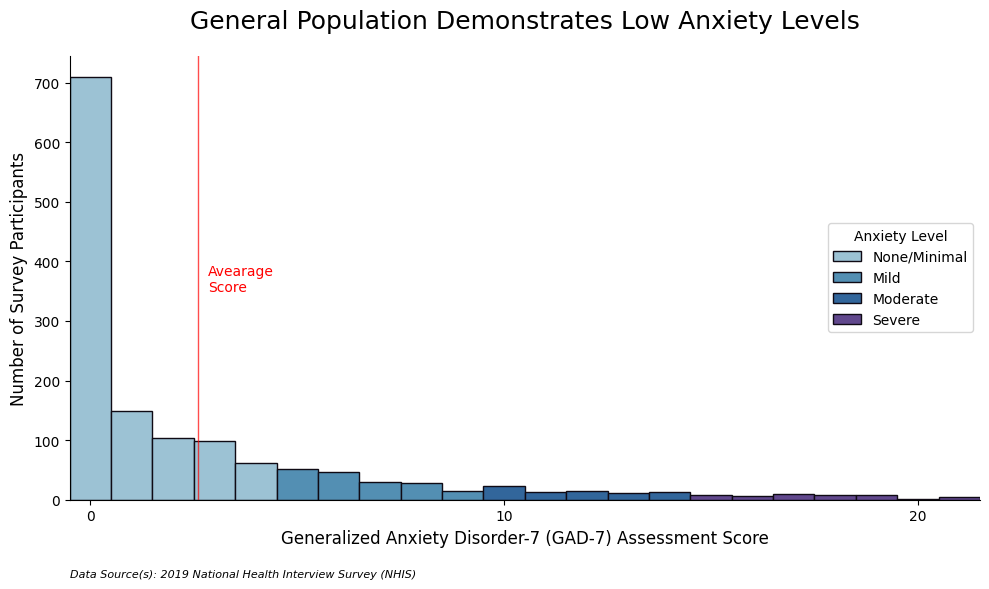

In [8]:
display_GAD_countplot(nhis_GAD_scores_result, 350, 'General Population Demonstrates Low Anxiety Levels', source_NHIS_title_countplot, 0, -50, 'nhis_gad_countplot')

### Conclusion:
Overall, Gamers exhibited a higher GAD-7 score than the General Population, though the average score fell just beyond the "Mild Anxiety" threshold. This is higher, but not as significantly different as I expected to see. 

## How did the GAD categorizations compare between gamers and the general population?

### GAD Categories by Percentage Queries

In [9]:
def get_GAD_cat_percentages_query(survey_id):
    return f"""
    SELECT
        g.GAD_cat,
        c.cat_name,
        COUNT(*) AS sum_participants,
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER () AS percentage
    FROM gad_data_usa_18_22 g
    JOIN GAD_category c on c.GAD_cat = g.GAD_cat
    WHERE survey_id = {survey_id}
    GROUP BY g.GAD_cat
    ORDER BY g.GAD_cat
    """

gamer_GAD_cat_percentages_query = get_GAD_cat_percentages_query(1)
gamer_GAD_cat_percentages_response = pd.read_sql(gamer_GAD_cat_percentages_query, conn)
gamer_GAD_cat_percent_series = pd.read_sql(gamer_GAD_cat_percentages_query, conn, index_col='cat_name')['percentage']


nhis_GAD_cat_percentages_query = get_GAD_cat_percentages_query(2)
nhis_GAD_cat_percentages_response = pd.read_sql(nhis_GAD_cat_percentages_query, conn)
nhis_GAD_cat_percent_series = pd.read_sql(nhis_GAD_cat_percentages_query, conn, index_col='cat_name')['percentage']

### Pie Chart Function

In [10]:
source_GAD_title_pie = 'Gaming Habits and Psychological Well-being: An international dataset about the\nAnxiety, Life Satisfaction and Social Phobia of over 13000 gamers'
source_NHIS_title_pie = '2019 National Health Interview Survey (NHIS)'

In [11]:
def display_GAD_pie_chart (series_name, plot_name, data_source_name, x_coord, y_coord, file_name):
    fig, ax = plt.subplots(figsize=(8,8))

    ax.pie(
        series_name,
        colors = colors_ld,
        # labels=series_name.index,
        autopct='%1.1f%%',
        textprops={'fontsize': 16,
                    'weight' : 'bold'}
        )

    ax.set_title(plot_name, fontsize=18)

    ax.legend(
        labels = series_name.index,
        loc="lower right",
        title = "Anxiety Level"
    )

    # Cite sources
    annotate_plot(data_source_name, x_coord, y_coord)

    # Save figure as image
    plt.savefig(f'../plots/{file_name}.png')

    plt.tight_layout()
    plt.show()

# Reference(s):
#   https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_features.html

### GAD Categorization Visualizations

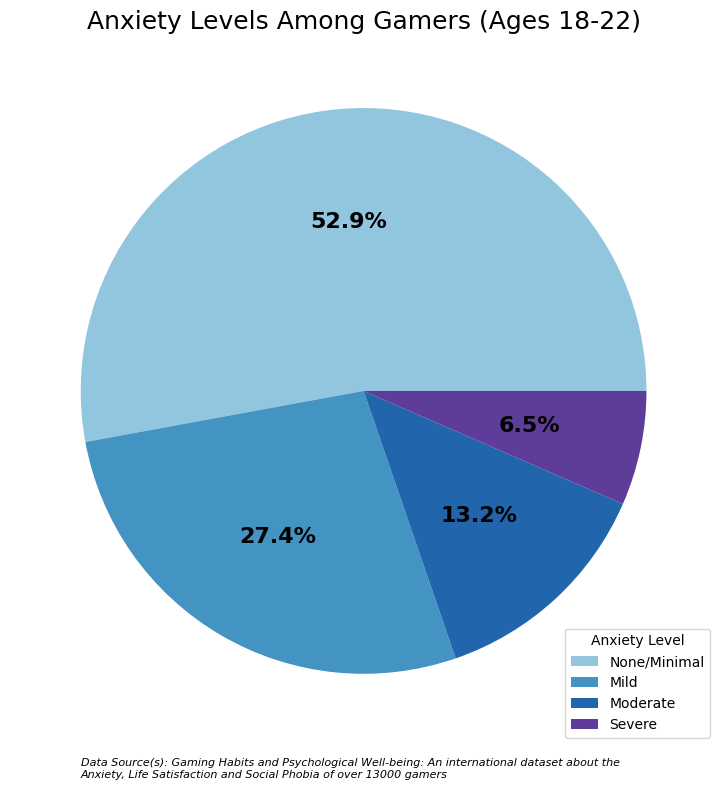

In [12]:
display_GAD_pie_chart(gamer_GAD_cat_percent_series, 'Anxiety Levels Among Gamers (Ages 18-22)', source_GAD_title_pie, 0.1, -10, 'gamer_gad_pie')

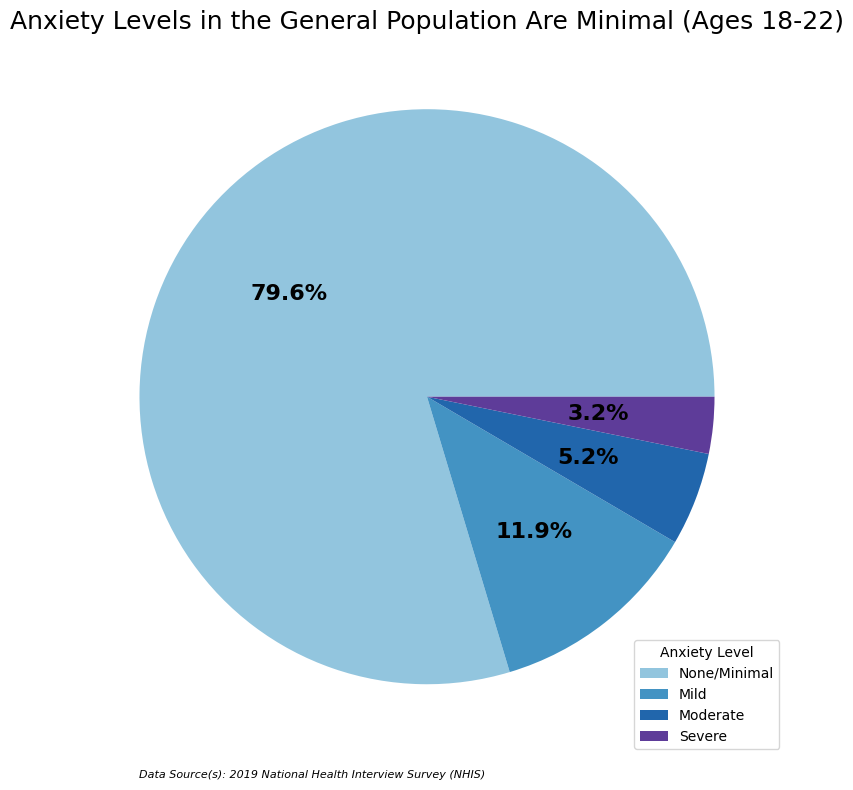

In [13]:
display_GAD_pie_chart(nhis_GAD_cat_percent_series, 'Anxiety Levels in the General Population Are Minimal (Ages 18-22)', source_NHIS_title_pie, 0.1, -10, 'nhis_gad_pie')

### Conclusion:
While the average GAD-7 score was just over the "Mild Anxiety" threshold for Gamers, there was a greater representation of individuals with levels higher than "Mild" in that group than in the general population.

## Did hours spent gaming impact participant's GAD score?
- This will use just the gaming data. (Keeping 18-22 year olds in USA)
- Histogram, Scatterplot, or Count Plot

### Gaming Hours and GAD Score Query

In [14]:
hours_GAD_scores_query = ("""
    SELECT
        p.participant_id,
        gad.GAD_total,
        game.hours
    FROM participant p
    JOIN GAD_response gad on gad.participant_id = p.participant_id
    JOIN gaming_response game on game.participant_id = p.participant_id
    WHERE p.survey_id = 1
        AND p.residence = 'USA'
""")

hours_GAD_scores_response = pd.read_sql(hours_GAD_scores_query, conn)

### Gaming Hours Visualization

In [15]:
source_GAD_title_scatter = 'Gaming Habits and Psychological Well-being: An international dataset about the Anxiety, Life Satisfaction and Social Phobia\nof over 13000 gamers'


In [16]:
def label_line(x_coord, y_coord, label, color_name):
    ax.text(
        x_coord,
        y_coord,
        f"{label}",
        color=color_name,
        fontsize=10,
        ha='right'
    )

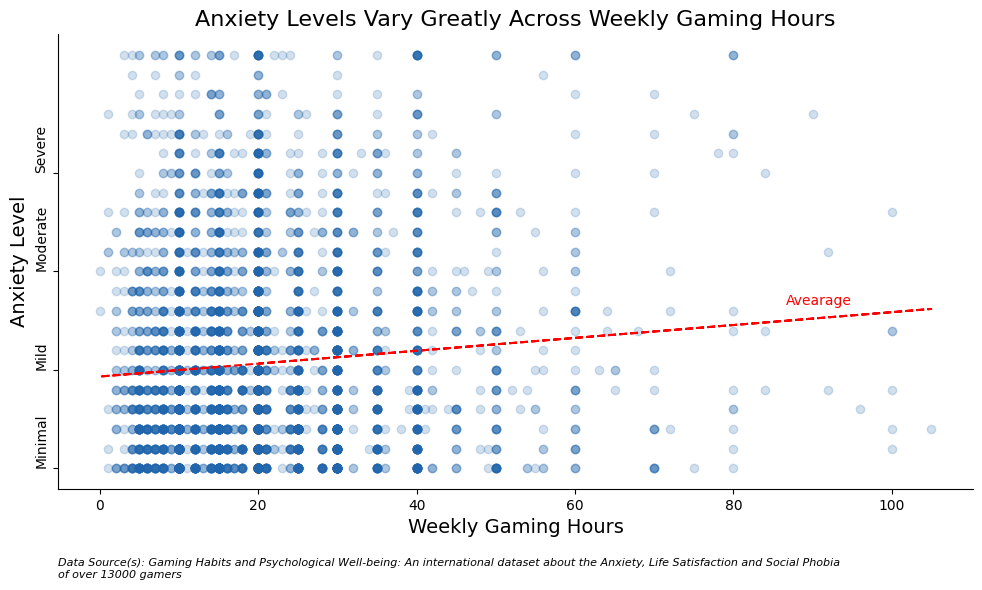

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(
    hours_GAD_scores_response['hours'], 
    hours_GAD_scores_response['GAD_total'],
    color = colors_dl[3],
    alpha = 0.2,
    # s = 25 # changes plot size
    )

plt.xlabel('Weekly Gaming Hours', fontsize=14)
plt.ylabel('Anxiety Level', fontsize=14)
plt.title('Anxiety Levels Vary Greatly Across Weekly Gaming Hours', fontsize=16)

plt.yticks([0, 5, 10, 15], ['Minimal', 'Mild', 'Moderate', 'Severe'], rotation=90, va='bottom')

ax = plt.gca()
remove_top_right_borders(ax)

# Draw trend line
x = hours_GAD_scores_response['hours']
y = hours_GAD_scores_response['GAD_total']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), 'r--')

label_line(95, 8.3, 'Avearage', 'red')

# Cite sources
annotate_plot(source_GAD_title_scatter, 0, -50)

# Save figure as image
plt.savefig('../plots/gamer_gad_scatter.png')

plt.tight_layout()
plt.show()

# Reference(s):
#   https://stackoverflow.com/questions/41635448/how-can-i-draw-scatter-trend-line

### Conclusion:
Weekly gaming hours showed little correlation with individual's anxiety levels.

## How did gaming platform impact participant's anxiety levels?

### Gaming Platform and GAD Score Query

In [18]:
platform_GAD_query = ("""
    SELECT
        gad.GAD_total,
        gr.platform
    FROM participant p
    JOIN GAD_response gad on gad.participant_id = p.participant_id
    JOIN gaming_response gr on gr.participant_id = p.participant_id
    WHERE p.survey_id = 1
        AND (p.age BETWEEN 18 AND 22)
        AND p.residence = 'USA'
""")

platform_GAD_response = pd.read_sql(platform_GAD_query, conn)
platform_GAD_response

,GAD_total,platform
0,19,PC
1,0,PC
2,3,Console
3,4,Console
4,1,PC
...,...,...
3387,1,PC
3388,11,PC
3389,2,PC
3390,6,PC


### Gaming Platform and GAD Score Visualization

In [19]:
platform_GAD_response['platform'].unique()

<StringArray>
['PC', 'Console', 'Mobile']
Length: 3, dtype: str

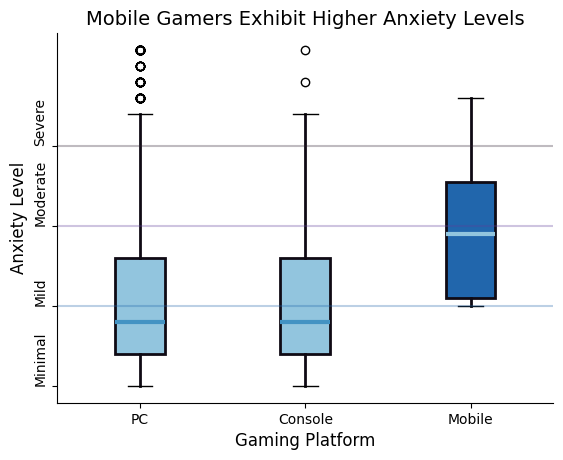

In [20]:
fig, ax = plt.subplots()

remove_top_right_borders(ax)

face_colors = [colors_ld[0], colors_ld[0], colors_ld[2]]
median_colors = [colors_ld[1], colors_ld[1], colors_ld[0]]

boxplot_style = {
    'whiskerprops': {'linewidth': 2, 'color': colors_dl[0]},
    'medianprops': {'linewidth': 3, 'color': colors_dl[2]},
    'boxprops': {'facecolor': colors_ld[0], 'edgecolor' : colors_dl[0], 'linewidth': 2}
}


bplot = ax.boxplot(
    [platform_GAD_response[platform_GAD_response['platform'] == 'PC']['GAD_total'],
    platform_GAD_response[platform_GAD_response['platform'] == 'Console']['GAD_total'],
    platform_GAD_response[platform_GAD_response['platform'] == 'Mobile']['GAD_total']
    ],
    tick_labels=['PC', 'Console', 'Mobile'],
    patch_artist=True,
    **boxplot_style,
)

for patch, face_color in zip(bplot['boxes'], face_colors):
    patch.set_facecolor(face_color)

for median, median_color in zip(bplot['medians'], median_colors):
    median.set_color(median_color)


plt.yticks([0, 5, 10, 15], ['Minimal', 'Mild', 'Moderate', 'Severe'], rotation=90, va='bottom', fontsize=10)
plt.axhline(y=5, color=colors_ld[2], linestyle='-', alpha = 0.3)
plt.axhline(y=10, color=colors_ld[3], linestyle='-', alpha = 0.3)
plt.axhline(y=15, color=colors_ld[4], linestyle='-', alpha = 0.3)

plt.xlabel('Gaming Platform', fontsize=12)
plt.ylabel('Anxiety Level', fontsize=12)
plt.title('Mobile Gamers Exhibit Higher Anxiety Levels', fontsize=14)

# Save figure as image
plt.savefig('../plots/gamer_gad_boxplot.png')


plt.show()

# Reference(s):
#   https://python-graph-gallery.com/542-custom-boxplots-matplotlib/
#   https://matplotlib.org/stable/gallery/statistics/boxplot_color.html
#   https://stackoverflow.com/questions/41997493/python-matplotlib-boxplot-color
#       I had to have ChatGPT help me figure out how to combine these ideas and find
#       the set_color syntax for the custom median colors.

### Conclusion:
Mobile gamers showed significantly higher anxiety levels than gamers on other platforms.